# Duplicate Payment Detection — Reconciliation Analysis

**Purpose:** Cross-validate Bronze vs Silver layers to prove the idempotency engine caught every duplicate correctly.

**What this notebook proves:**
1. Every event in Bronze has a corresponding decision in Silver
2. Every duplicate in Bronze was correctly rejected in Silver
3. No legitimate payment was incorrectly blocked
4. Latency SLA was met across all decisions
5. Duplicate rate per merchant is within expected bounds

In [5]:
import psycopg
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.facecolor'] = '#1e1e2e'
plt.rcParams['figure.facecolor'] = '#1e1e2e'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#444'
plt.rcParams['grid.color'] = '#333'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5

DB_CONN = {
    'host': 'localhost',
    'port': 5432,
    'dbname': 'payments_dw',
    'user': 'payments_user',
    'password': 'payments_pass'
}

def query(sql):
    with psycopg.connect(**DB_CONN) as conn:
        with conn.cursor() as cur:
            cur.execute(sql)
            columns = [desc[0] for desc in cur.description]
            rows = cur.fetchall()
            return pd.DataFrame(rows, columns=columns)

print('✓ Connected to PostgreSQL')
print('✓ Ready for reconciliation analysis')

✓ Connected to PostgreSQL
✓ Ready for reconciliation analysis


## 1. Layer Counts — Bronze vs Silver
Every event in Bronze must have exactly one decision in Silver.

In [6]:
counts = query("""
    SELECT 'Bronze (Raw Events)' AS layer, COUNT(*) AS total,
        COUNT(*) FILTER (WHERE is_retry_flag = TRUE)  AS duplicates,
        COUNT(*) FILTER (WHERE is_retry_flag = FALSE) AS fresh
    FROM bronze.payment_events
    UNION ALL
    SELECT 'Silver (Decisions)' AS layer, COUNT(*) AS total,
        COUNT(*) FILTER (WHERE dedup_status = 'REJECTED_DUPLICATE') AS duplicates,
        COUNT(*) FILTER (WHERE dedup_status = 'ACCEPTED')           AS fresh
    FROM silver.payment_decisions
""")
print('=' * 55)
print('  LAYER COUNT RECONCILIATION')
print('=' * 55)
print(counts.to_string(index=False))
print()
bronze_total = counts[counts['layer'] == 'Bronze (Raw Events)']['total'].values[0]
silver_total = counts[counts['layer'] == 'Silver (Decisions)']['total'].values[0]
if bronze_total == silver_total:
    print(f'✓ PASS — Bronze ({bronze_total:,}) = Silver ({silver_total:,})')
else:
    print(f'✗ FAIL — Bronze ({bronze_total:,}) != Silver ({silver_total:,})')

  LAYER COUNT RECONCILIATION
              layer  total  duplicates  fresh
Bronze (Raw Events)  10000        1542   8458
 Silver (Decisions)  10000        1542   8458

✓ PASS — Bronze (10,000) = Silver (10,000)


## 2. Duplicate Detection Accuracy
Every event flagged as a retry in Bronze must be REJECTED in Silver.

In [7]:
accuracy = query("""
    SELECT b.is_retry_flag, s.dedup_status, COUNT(*) as count
    FROM bronze.payment_events b
    JOIN silver.payment_decisions s ON b.payment_id = s.payment_id
    GROUP BY b.is_retry_flag, s.dedup_status
    ORDER BY b.is_retry_flag, s.dedup_status
""")
print('=' * 55)
print('  DUPLICATE DETECTION ACCURACY')
print('=' * 55)
print(accuracy.to_string(index=False))
print()
tp = accuracy[(accuracy['is_retry_flag']==True)  & (accuracy['dedup_status']=='REJECTED_DUPLICATE')]['count'].sum()
fn = accuracy[(accuracy['is_retry_flag']==True)  & (accuracy['dedup_status']=='ACCEPTED')]['count'].sum()
fp = accuracy[(accuracy['is_retry_flag']==False) & (accuracy['dedup_status']=='REJECTED_DUPLICATE')]['count'].sum()
tn = accuracy[(accuracy['is_retry_flag']==False) & (accuracy['dedup_status']=='ACCEPTED')]['count'].sum()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f'True Positives  (correctly blocked duplicates) : {tp:,}')
print(f'True Negatives  (correctly accepted fresh)     : {tn:,}')
print(f'False Positives (wrongly blocked fresh)        : {fp:,}')
print(f'False Negatives (missed duplicates)            : {fn:,}')
print(f'Precision : {precision:.2%}')
print(f'Recall    : {recall:.2%}')
if fp == 0 and fn == 0:
    print('\n✓ PASS — Perfect detection accuracy.')
else:
    print(f'\n⚠ Review needed — FP={fp:,} FN={fn:,}')

  DUPLICATE DETECTION ACCURACY
 is_retry_flag       dedup_status  count
         False           ACCEPTED   8458
          True REJECTED_DUPLICATE   1542

True Positives  (correctly blocked duplicates) : 1,542
True Negatives  (correctly accepted fresh)     : 8,458
False Positives (wrongly blocked fresh)        : 0
False Negatives (missed duplicates)            : 0
Precision : 100.00%
Recall    : 100.00%

✓ PASS — Perfect detection accuracy.


## 3. SLA Compliance — Latency Distribution

  SLA COMPLIANCE (Target: <50ms)
Within SLA (<50ms) : 10,000
Breached  (>=50ms) : 0
Compliance         : 100.00%
Avg latency        : 1.75ms
P95 latency        : 4.00ms
P99 latency        : 10.00ms
Max latency        : 36.00ms

✓ PASS — 100% SLA compliance. All decisions under 50ms.


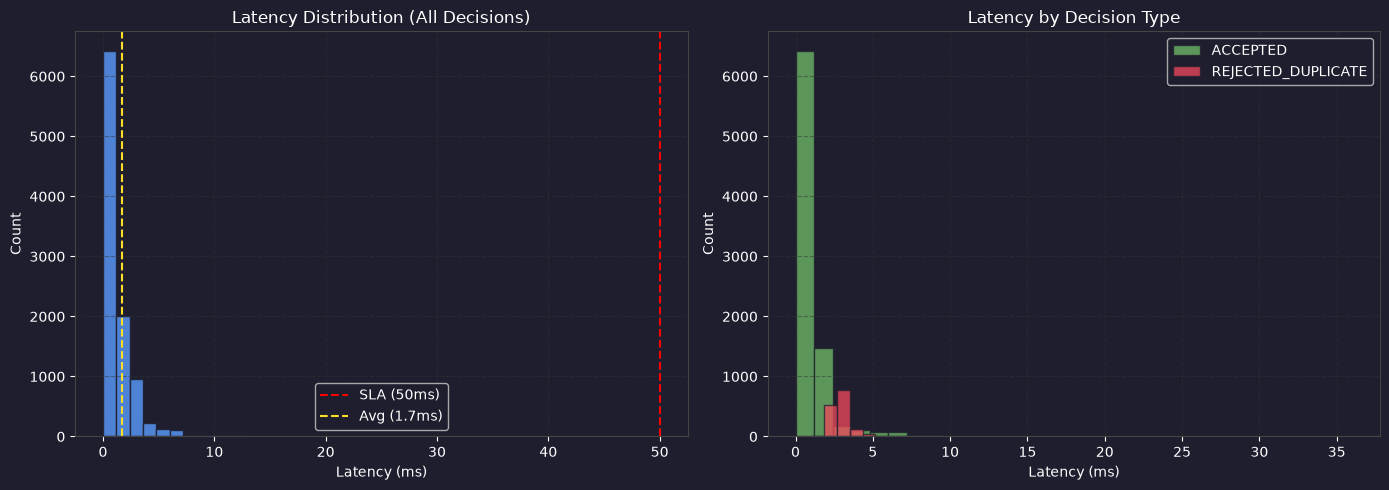

In [8]:
latency = query("SELECT processing_latency_ms, dedup_status FROM silver.payment_decisions")
SLA_TARGET = 50
within_sla = (latency['processing_latency_ms'] < SLA_TARGET).sum()
breached   = (latency['processing_latency_ms'] >= SLA_TARGET).sum()
compliance = within_sla / len(latency) * 100
print('=' * 55)
print('  SLA COMPLIANCE (Target: <50ms)')
print('=' * 55)
print(f'Within SLA (<50ms) : {within_sla:,}')
print(f'Breached  (>=50ms) : {breached:,}')
print(f'Compliance         : {compliance:.2f}%')
print(f'Avg latency        : {latency["processing_latency_ms"].mean():.2f}ms')
print(f'P95 latency        : {latency["processing_latency_ms"].quantile(0.95):.2f}ms')
print(f'P99 latency        : {latency["processing_latency_ms"].quantile(0.99):.2f}ms')
print(f'Max latency        : {latency["processing_latency_ms"].max():.2f}ms')
print()
if compliance == 100.0:
    print('✓ PASS — 100% SLA compliance. All decisions under 50ms.')
else:
    print(f'⚠ {breached:,} decisions breached SLA target.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
accepted = latency[latency['dedup_status']=='ACCEPTED']['processing_latency_ms']
rejected = latency[latency['dedup_status']=='REJECTED_DUPLICATE']['processing_latency_ms']
axes[0].hist(latency['processing_latency_ms'], bins=30, color='#5794F2', edgecolor='#1e1e2e', alpha=0.85)
axes[0].axvline(SLA_TARGET, color='red', linestyle='--', linewidth=1.5, label=f'SLA ({SLA_TARGET}ms)')
axes[0].axvline(latency['processing_latency_ms'].mean(), color='#FADE2A', linestyle='--', linewidth=1.5, label=f'Avg ({latency["processing_latency_ms"].mean():.1f}ms)')
axes[0].set_title('Latency Distribution (All Decisions)')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True)
axes[1].hist(accepted, bins=30, color='#73BF69', edgecolor='#1e1e2e', alpha=0.75, label='ACCEPTED')
axes[1].hist(rejected, bins=30, color='#F2495C', edgecolor='#1e1e2e', alpha=0.75, label='REJECTED_DUPLICATE')
axes[1].set_title('Latency by Decision Type')
axes[1].set_xlabel('Latency (ms)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Duplicate Rate by Merchant

  DUPLICATE RATE BY MERCHANT
         merchant_id  total  accepted  rejected duplicate_rate_pct
       merchant_kuda    955       793       162              16.96
   merchant_paystack   1075       894       181              16.84
merchant_flutterwave   1049       881       168              16.02
    merchant_palmpay   1007       851       156              15.49
       merchant_opay    988       836       152              15.38
     merchant_access   1025       868       157              15.32
  merchant_firstbank   1028       871       157              15.27
 merchant_moniepoint    971       830       141              14.52
     merchant_gtbank    961       825       136              14.15
     merchant_zenith    941       809       132              14.03


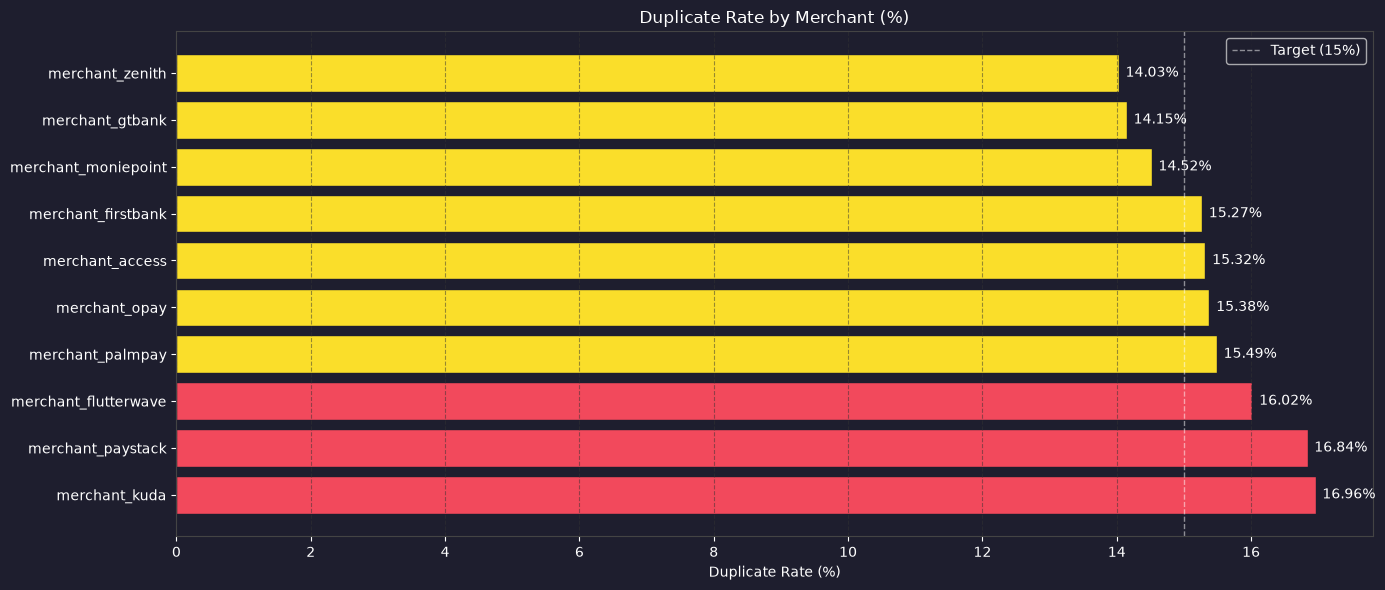

In [9]:
merchant = query("""
    SELECT merchant_id, COUNT(*) AS total,
        COUNT(*) FILTER (WHERE dedup_status = 'ACCEPTED')           AS accepted,
        COUNT(*) FILTER (WHERE dedup_status = 'REJECTED_DUPLICATE') AS rejected,
        ROUND(COUNT(*) FILTER (WHERE dedup_status = 'REJECTED_DUPLICATE')::NUMERIC / COUNT(*) * 100, 2) AS duplicate_rate_pct
    FROM silver.payment_decisions
    GROUP BY merchant_id
    ORDER BY duplicate_rate_pct DESC
""")
print('=' * 65)
print('  DUPLICATE RATE BY MERCHANT')
print('=' * 65)
print(merchant.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#F2495C' if r > 16 else '#FADE2A' if r > 14 else '#73BF69' for r in merchant['duplicate_rate_pct']]
bars = ax.barh(merchant['merchant_id'], merchant['duplicate_rate_pct'], color=colors, edgecolor='#1e1e2e')
ax.axvline(15, color='white', linestyle='--', linewidth=1, alpha=0.5, label='Target (15%)')
ax.set_title('Duplicate Rate by Merchant (%)')
ax.set_xlabel('Duplicate Rate (%)')
ax.legend()
ax.grid(True, axis='x')
for bar, val in zip(bars, merchant['duplicate_rate_pct']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', color='white', fontsize=10)
plt.tight_layout()
plt.savefig('merchant_duplicate_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Final Reconciliation Summary

In [10]:
summary = query("""
    SELECT
        (SELECT COUNT(*) FROM bronze.payment_events) AS bronze_total,
        (SELECT COUNT(*) FROM silver.payment_decisions) AS silver_total,
        (SELECT COUNT(*) FROM silver.payment_decisions WHERE dedup_status = 'ACCEPTED') AS accepted,
        (SELECT COUNT(*) FROM silver.payment_decisions WHERE dedup_status = 'REJECTED_DUPLICATE') AS rejected,
        (SELECT ROUND(AVG(processing_latency_ms)::NUMERIC, 2) FROM silver.payment_decisions) AS avg_latency_ms,
        (SELECT ROUND(PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY processing_latency_ms)::NUMERIC, 2) FROM silver.payment_decisions) AS p99_latency_ms,
        (SELECT COUNT(*) FROM silver.payment_decisions WHERE processing_latency_ms >= 50) AS sla_breaches,
        (SELECT COUNT(*) FROM gold.customer_retry_patterns_daily WHERE flagged_for_review = TRUE) AS flagged_customers
""")
s = summary.iloc[0]
dupe_rate = s['rejected'] / s['bronze_total'] * 100
print()
print('╔══════════════════════════════════════════════════════════╗')
print('║         FINAL RECONCILIATION REPORT                     ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Bronze events received     : {int(s["bronze_total"]):>10,}               ║')
print(f'║  Silver decisions written   : {int(s["silver_total"]):>10,}               ║')
print(f'║  Accepted (legitimate)      : {int(s["accepted"]):>10,}               ║')
print(f'║  Rejected (duplicates)      : {int(s["rejected"]):>10,}               ║')
print(f'║  Duplicate rate             : {dupe_rate:>10.1f}%               ║')
print(f'║  Avg processing latency     : {float(s["avg_latency_ms"]):>10.2f}ms              ║')
print(f'║  P99 processing latency     : {float(s["p99_latency_ms"]):>10.2f}ms              ║')
print(f'║  SLA breaches (>=50ms)      : {int(s["sla_breaches"]):>10,}               ║')
print(f'║  Customers flagged          : {int(s["flagged_customers"]):>10,}               ║')
print('╠══════════════════════════════════════════════════════════╣')
all_pass = s['bronze_total'] == s['silver_total'] and s['sla_breaches'] == 0
status = '✓ ALL CHECKS PASSED' if all_pass else '⚠ REVIEW REQUIRED'
print(f'║  Status: {status:<49}║')
print('╚══════════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════════╗
║         FINAL RECONCILIATION REPORT                     ║
╠══════════════════════════════════════════════════════════╣
║  Bronze events received     :     10,000               ║
║  Silver decisions written   :     10,000               ║
║  Accepted (legitimate)      :      8,458               ║
║  Rejected (duplicates)      :      1,542               ║
║  Duplicate rate             :       15.4%               ║
║  Avg processing latency     :       1.75ms              ║
║  P99 processing latency     :      10.00ms              ║
║  SLA breaches (>=50ms)      :          0               ║
║  Customers flagged          :          1               ║
╠══════════════════════════════════════════════════════════╣
║  Status: ✓ ALL CHECKS PASSED                              ║
╚══════════════════════════════════════════════════════════╝
